In [148]:
import pandas as pd
import numpy as np
import re
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [149]:
HL_base = pd.read_csv("C:/Users/Jesse/OneDrive/Desktop/QSS20_WI26/Final Project/trafficking_states_master.csv")
HL_base = HL_base.drop(columns=["% of total signals", "% of total cases"])
HL_base.head()

,State,Signals received,Cases identified,Year
0,Alabama,231,105,2024
1,Alaska,46,22,2024
2,Arizona,550,300,2024
3,Arkansas,170,80,2024
4,California,3378,1733,2024


In [150]:
ICE_base = pd.read_csv("C:/Users/Jesse/OneDrive/Desktop/QSS20_WI26/Final Project/ICERemovalsdata.csv",
                      encoding='latin-1')


In [151]:
ICE_base = ICE_base.drop(columns=["Criminality", "Arresting Agency", "Criminality", "Country of Citizenship", "Fiscal Quarter", "Fiscal Month", "Month-Year"])

In [152]:
ICE_byyear = ICE_base.groupby(["Area of Responsibility (AOR)", "Fiscal Year"])["Removals"].sum().reset_index()

In [153]:
ICE_byyear

,Area of Responsibility (AOR),Fiscal Year,Removals
0,Atlanta,2021,2780
1,Atlanta,2022,2598
2,Atlanta,2023,5002
3,Atlanta,2024,6277
4,Atlanta,2025,978
...,...,...,...
119,Washington,2021,319
120,Washington,2022,75
121,Washington,2023,353
122,Washington,2024,820


In [154]:
AOR_merge = pd.read_csv("C:/Users/Jesse/OneDrive/Desktop/QSS20_WI26/Final Project/ICEEROmanualdatacleancompleted.csv")

In [155]:
AOR_merge["office_name"] = AOR_merge["office_name"].str.replace(" Field Office", "", regex=False).str.strip()

AOR_merge.head()

,office_name,office_name_short,area
0,Atlanta,Atlanta - ERO,"['Georgia', 'North Carolina', 'South Carolina']"
1,Baltimore,Baltimore - ERO,['Maryland']
2,Buffalo,Buffalo - ERO,['New York']
3,Boston,Burlington - ERO,"['Connecticut', 'Maine', 'Massachusetts', 'New..."
4,Denver,Centennial - ERO,"['Colorado', 'Wyoming']"


In [156]:
AOR_areas_exploded = AOR_merge.explode("area").reset_index(drop=True)

In [157]:
AOR_merge["area"] = AOR_merge["area"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
areas_exploded = AOR_merge.explode("area").reset_index(drop=True)

In [158]:
HL_merged = pd.merge(HL_base, areas_exploded, left_on="State", right_on="area", how="left")

In [159]:
HL_byAOR = HL_merged.groupby(["office_name", "Year"])[["Signals received", "Cases identified"]].sum().reset_index()

In [160]:
HL_ICE_merged = pd.merge(HL_byAOR, ICE_byyear, left_on=["office_name", "Year"], right_on=["Area of Responsibility (AOR)", "Fiscal Year"], how="right")

HL_ICE_merged = HL_ICE_merged[~HL_ICE_merged["Fiscal Year"].isin([2025])]


In [161]:
HL_ICE_merged

,office_name,Year,Signals received,Cases identified,Area of Responsibility (AOR),Fiscal Year,Removals
0,Atlanta,2021.0,2447.0,629.0,Atlanta,2021,2780
1,Atlanta,2022.0,1946.0,573.0,Atlanta,2022,2598
2,Atlanta,2023.0,1467.0,567.0,Atlanta,2023,5002
3,Atlanta,2024.0,1781.0,779.0,Atlanta,2024,6277
5,Baltimore,2024.0,358.0,179.0,Baltimore,2024,65
...,...,...,...,...,...,...,...
117,St. Paul,2024.0,662.0,297.0,St. Paul,2024,853
119,Washington,2021.0,778.0,185.0,Washington,2021,319
120,Washington,2022.0,690.0,199.0,Washington,2022,75
121,Washington,2023.0,685.0,204.0,Washington,2023,353


In [166]:
HL_ICE_merged = HL_ICE_merged.dropna()
HL_ICE_merged = HL_ICE_merged.rename(columns={
    "Signals received": "Signals_received",
    "Fiscal Year": "Fiscal_Year",
    "Cases identified": "Cases_identified",
    "Area of Responsibility (AOR)": "AOR"
})

HL_ICE_merged

,office_name,Year,Signals_received,Cases_identified,AOR,Fiscal_Year,Removals
0,Atlanta,2021.0,2447.0,629.0,Atlanta,2021,2780
1,Atlanta,2022.0,1946.0,573.0,Atlanta,2022,2598
2,Atlanta,2023.0,1467.0,567.0,Atlanta,2023,5002
3,Atlanta,2024.0,1781.0,779.0,Atlanta,2024,6277
5,Baltimore,2024.0,358.0,179.0,Baltimore,2024,65
...,...,...,...,...,...,...,...
117,St. Paul,2024.0,662.0,297.0,St. Paul,2024,853
119,Washington,2021.0,778.0,185.0,Washington,2021,319
120,Washington,2022.0,690.0,199.0,Washington,2022,75
121,Washington,2023.0,685.0,204.0,Washington,2023,353


In [168]:
HL__Signal__on_year_rem_ = smf.ols("Signals_received ~ Removals", data=HL_ICE_merged).fit()
print(HL__Signal__on_year_rem_.summary())

                            OLS Regression Results                            
Dep. Variable:       Signals_received   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     1.303
Date:                Wed, 04 Mar 2026   Prob (F-statistic):              0.257
Time:                        21:58:23   Log-Likelihood:                -773.07
No. Observations:                  91   AIC:                             1550.
Df Residuals:                      89   BIC:                             1555.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1792.3523    139.724     12.828      0.0

In [169]:
HL__Signal__on_year_rem_ = smf.ols("Signals_received ~ Removals + C(Fiscal_Year) + C(AOR)", data=HL_ICE_merged).fit()
print(HL__Signal__on_year_rem_.summary())

                            OLS Regression Results                            
Dep. Variable:       Signals_received   R-squared:                       0.964
Model:                            OLS   Adj. R-squared:                  0.949
Method:                 Least Squares   F-statistic:                     62.58
Date:                Wed, 04 Mar 2026   Prob (F-statistic):           6.85e-36
Time:                        21:59:03   Log-Likelihood:                -622.41
No. Observations:                  91   AIC:                             1301.
Df Residuals:                      63   BIC:                             1371.
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

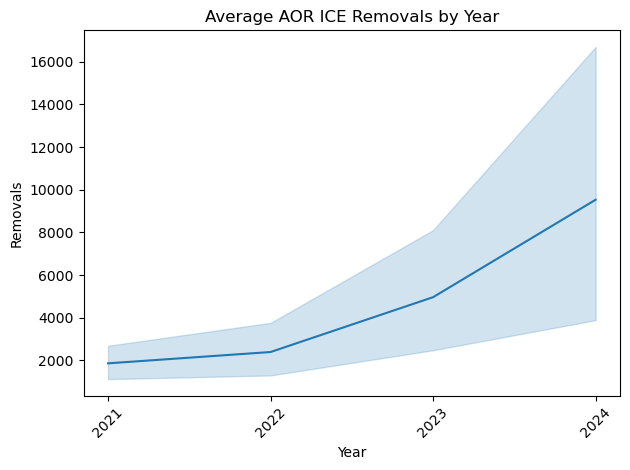

In [173]:
#Line Column for Change By Year
sns.lineplot(data=HL_ICE_merged, x='Fiscal_Year', y='Removals')
plt.title('Average AOR ICE Removals by Year')
plt.xlabel('Year')
plt.xticks([2021, 2022, 2023, 2024], rotation=45)
plt.ylabel('Removals')
plt.tight_layout()
plt.show()

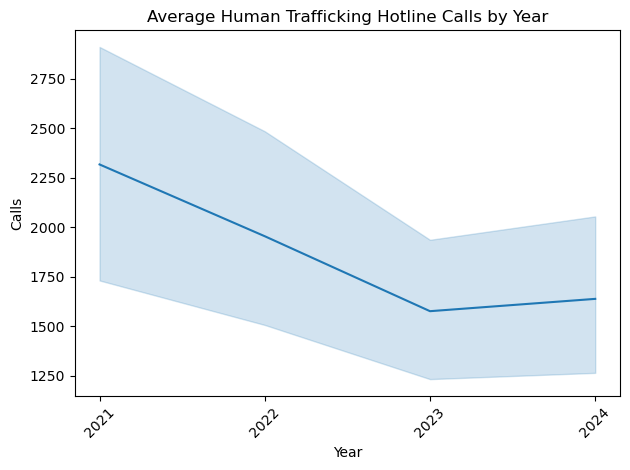

In [175]:
#Line Column for Change By Year
sns.lineplot(data=HL_ICE_merged, x='Fiscal_Year', y='Signals_received')
plt.title('Average Human Trafficking Hotline Calls by Year')
plt.xlabel('Year')
plt.xticks([2021, 2022, 2023, 2024], rotation=45)
plt.ylabel('Calls')
plt.tight_layout()
plt.show()